In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('Dataset/archive(3)/Car_Price_Prediction.csv')
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


# Observation
- Dataset has 1000 rows and 8 columns
- `Price` is the target column
- We have both numerical and categorical columns

In [4]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


# Observation
- Car year ranges from 2000 to 2021
- Engine size is between 1.0 and 4.5
- Mileage and price both have a wide spread

In [5]:
df.nunique()

Make               5
Model              5
Year              22
Engine Size       36
Mileage          997
Fuel Type          3
Transmission       2
Price           1000
dtype: int64

# Observation
- `Make`, `Model`, `Fuel Type` and `Transmission` are categorical columns
- These columns have small number of unique values so they can be encoded later if needed

In [6]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

# Observation
- There are no missing values in this dataset
- Since the dataset is already clean, we can directly analyze relationships

In [7]:
df['Make'].value_counts()

Make
Ford      225
Audi      212
Honda     198
Toyota    187
BMW       178
Name: count, dtype: int64

In [8]:
df['Fuel Type'].value_counts()

Fuel Type
Diesel      344
Petrol      331
Electric    325
Name: count, dtype: int64

In [9]:
df['Transmission'].value_counts()

Transmission
Manual       511
Automatic    489
Name: count, dtype: int64

# Observation
- Category distribution is fairly balanced
- No category is extremely rare

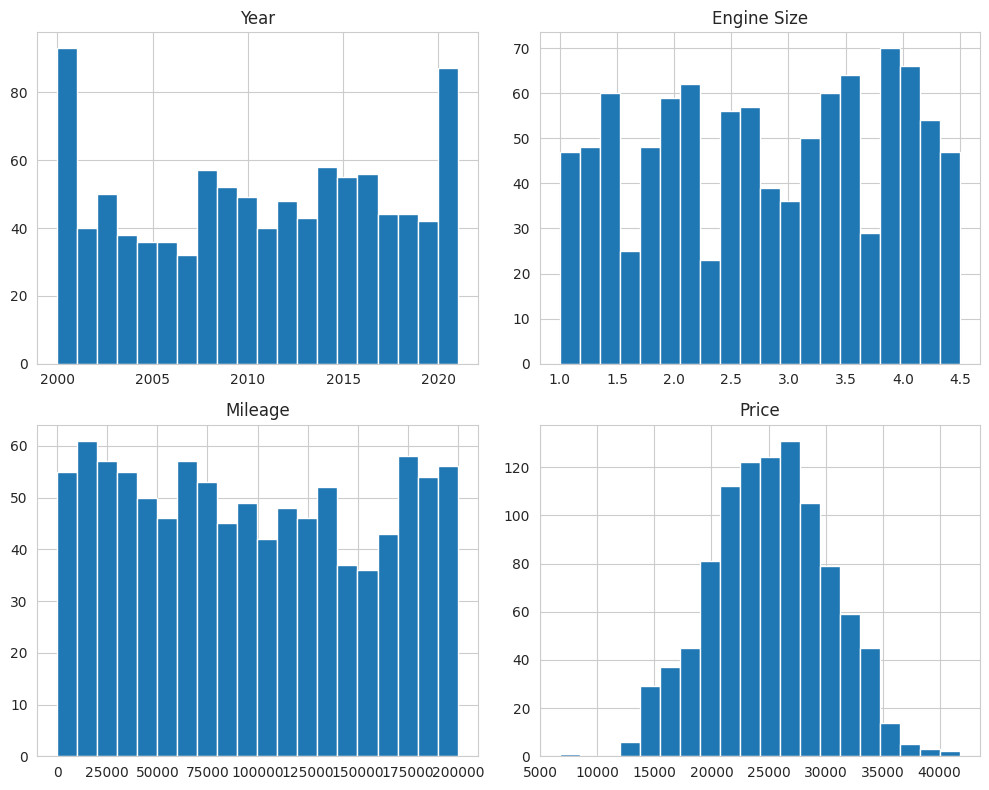

In [10]:
num_cols = ['Year', 'Engine Size', 'Mileage', 'Price']
df[num_cols].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

# Observation
- `Year` looks fairly spread across many years
- `Mileage` has large variation
- `Price` looks reasonably continuous for regression

In [11]:
df[num_cols].corr()

,Year,Engine Size,Mileage,Price
Year,1.000000,-0.012190,0.016376,0.609631
Engine Size,-0.012190,1.000000,-0.014815,0.383951
Mileage,0.016376,-0.014815,1.000000,-0.556560
Price,0.609631,0.383951,-0.556560,1.000000


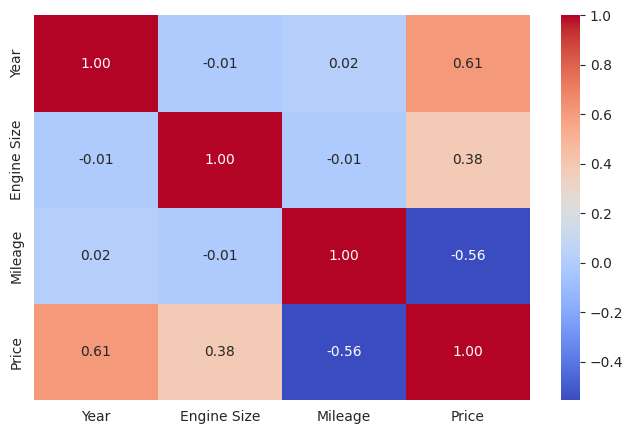

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# Observation
- `Year` has positive correlation with `Price`
- `Mileage` has negative correlation with `Price`
- `Engine Size` also has positive relation with `Price`

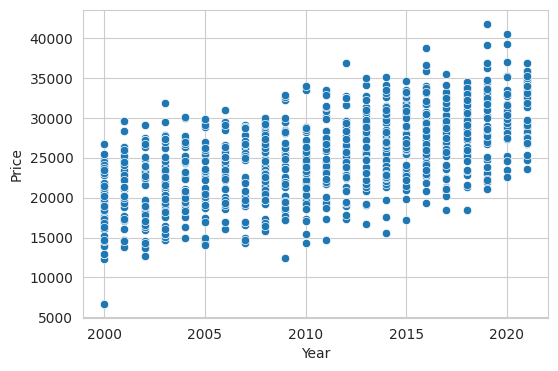

In [13]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Year', y='Price')
plt.show()

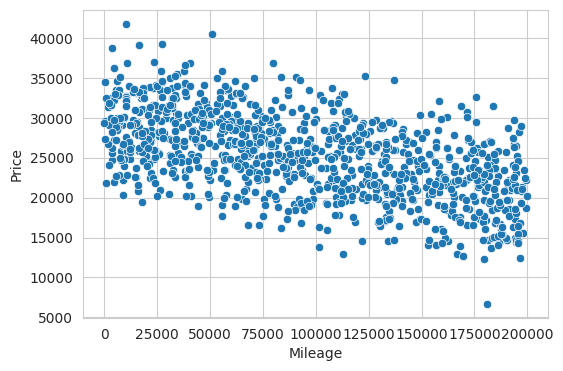

In [14]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Mileage', y='Price')
plt.show()

# Final Observation
- Newer cars tend to have higher price
- Cars with higher mileage tend to have lower price
- For simple linear regression, `Year` or `Mileage` are the best columns to start with

# Feature Engineering
- For multiple regression models, we should prepare categorical columns and create one meaningful feature
- We will create `Car Age` and encode the categorical columns

In [15]:
df_fe = df.copy()
current_year = pd.Timestamp.today().year
df_fe['Car Age'] = current_year - df_fe['Year']
df_fe.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931,11
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684,12
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347,20
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491,11
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657,22


In [16]:
df_fe[['Year', 'Car Age', 'Engine Size', 'Mileage', 'Price']].corr()

,Year,Car Age,Engine Size,Mileage,Price
Year,1.000000,-1.000000,-0.012190,0.016376,0.609631
Car Age,-1.000000,1.000000,0.012190,-0.016376,-0.609631
Engine Size,-0.012190,0.012190,1.000000,-0.014815,0.383951
Mileage,0.016376,-0.016376,-0.014815,1.000000,-0.556560
Price,0.609631,-0.609631,0.383951,-0.556560,1.000000


# Observation
- `Car Age` is easier to understand than raw year
- Since `Car Age` and `Year` represent the same information, we will keep only one of them in the model

In [17]:
df_model = df_fe.drop(columns='Year')
df_model = pd.get_dummies(df_model, columns=['Make', 'Model', 'Fuel Type', 'Transmission'], drop_first=True,dtype=int)
df_model.head()

,Engine Size,Mileage,Price,Car Age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,3.9,74176,30246.207931,11,0,0,1,0,1,0,0,0,0,1,1
1,1.7,94799,22785.747684,12,0,1,0,0,0,1,0,0,1,0,0
2,4.1,98385,25760.290347,20,1,0,0,0,1,0,0,0,1,0,1
3,2.6,88919,25638.003491,11,0,0,1,0,1,0,0,0,1,0,0
4,3.4,138482,21021.386657,22,0,0,1,0,0,1,0,0,0,1,0


In [18]:
encoded_cols = ['Make_BMW', 'Make_Ford', 'Make_Honda', 'Make_Toyota',
                'Model_Model B', 'Model_Model C', 'Model_Model D', 'Model_Model E',
                'Fuel Type_Electric', 'Fuel Type_Petrol', 'Transmission_Manual']

correlation = df_model[encoded_cols + ['Price']].corr()['Price'].drop('Price').sort_values(ascending=False)
print(correlation)

Make_Honda             0.054260
Make_Ford              0.020064
Model_Model D          0.013165
Model_Model C          0.011217
Fuel Type_Electric     0.011038
Model_Model E          0.006704
Model_Model B          0.005426
Make_BMW              -0.006690
Fuel Type_Petrol      -0.010698
Make_Toyota           -0.020740
Transmission_Manual   -0.025582
Name: Price, dtype: float64


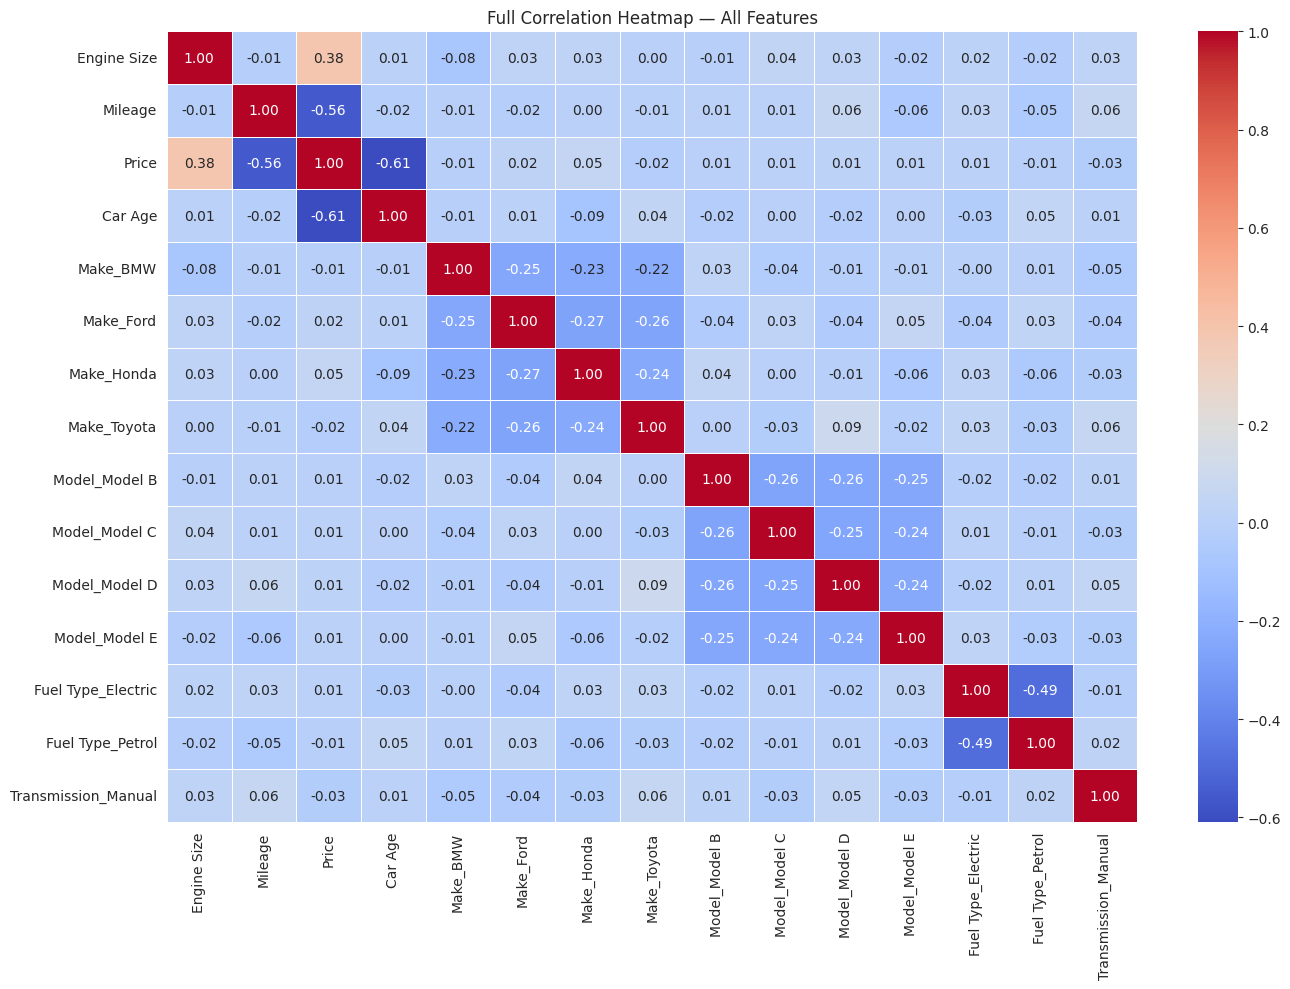

In [19]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_model.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Full Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()

# Observation
- Categorical columns are converted into numeric columns
- Now the dataset is ready for regression models like Linear, Ridge, Lasso and Random Forest Regressor

# Feature Selection
- We will first check the important numeric features
- Then we will rank all engineered features using `SelectKBest`

In [20]:
df_fe[['Car Age', 'Engine Size', 'Mileage', 'Price']].corr()['Price'].sort_values(ascending=False)

Price          1.000000
Engine Size    0.383951
Mileage       -0.556560
Car Age       -0.609631
Name: Price, dtype: float64

In [21]:
from sklearn.feature_selection import SelectKBest, f_regression

In [22]:
X = df_model.drop(columns='Price')
y = df_model['Price']

selector = SelectKBest(score_func=f_regression, k=10)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

feature_scores.head(10)

,Feature,Score
2,Car Age,590.286363
1,Mileage,447.871416
0,Engine Size,172.562892
5,Make_Honda,2.946907
13,Transmission_Manual,0.653566
6,Make_Toyota,0.429489
4,Make_Ford,0.401904
9,Model_Model D,0.173002
8,Model_Model C,0.125588
11,Fuel Type_Electric,0.121599


# Final Conclusion
- For simple regression, `Year`, `Car Age` or `Mileage` are the best starting features
- For multiple regression, use the engineered dataset `df_model`
- we need to drop all other columns other than `Car Age`, `Mileage` and `Engine size` 
- We should not keep both `Year` and `Car Age` together because they carry the same information

In [23]:
df_model.sample(5)

,Engine Size,Mileage,Price,Car Age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
619,3.9,59099,29264.227872,9,0,0,1,0,1,0,0,0,1,0,1
567,2.1,122058,29151.264517,5,0,0,1,0,0,0,1,0,0,0,0
139,3.9,80983,23157.281688,23,0,0,0,1,0,0,0,0,0,1,0
233,3.0,38379,23274.522865,26,0,0,0,0,0,0,1,0,0,1,1
152,1.6,141292,25706.864934,9,0,0,1,0,1,0,0,0,0,1,0


In [24]:
df_model.columns.tolist()

['Engine Size',
 'Mileage',
 'Price',
 'Car Age',
 'Make_BMW',
 'Make_Ford',
 'Make_Honda',
 'Make_Toyota',
 'Model_Model B',
 'Model_Model C',
 'Model_Model D',
 'Model_Model E',
 'Fuel Type_Electric',
 'Fuel Type_Petrol',
 'Transmission_Manual']

In [25]:
df_model_main=df_model.drop(columns=['Make_BMW',
 'Make_Ford',
 'Make_Honda',
 'Make_Toyota',
 'Model_Model B',
 'Model_Model C',
 'Model_Model D',
 'Model_Model E',
 'Fuel Type_Electric',
 'Fuel Type_Petrol','Transmission_Manual'])

In [53]:
df_model_full = df_model

## Simple Linear Regression


In [26]:
X = df_model_main['Car Age']
y= df_model_main['Price']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2, random_state=2)

In [28]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()

In [29]:
X_train.shape

(800,)

In [30]:
X_train_reshaped = X_train.values.reshape(-1, 1)
X_test_reshaped = X_test.values.reshape(-1, 1)

In [31]:
X_test_reshaped.shape

(200, 1)

In [32]:
lr.fit(X_train_reshaped,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_test, X_test

(37     16604.498170
 726    24531.174724
 846    32431.531353
 295    40538.382064
 924    30434.529368
            ...     
 839    23566.247511
 810    16363.006005
 930    17309.141320
 616    21952.607630
 809    25710.803679
 Name: Price, Length: 200, dtype: float64,
 37     26
 726    23
 846     7
 295     6
 924     6
        ..
 839    17
 810    22
 930    16
 616     7
 809     9
 Name: Car Age, Length: 200, dtype: int64)

In [34]:
lr.predict(X_test_reshaped[[2]])

array([29355.89050954])

Text(0, 0.5, 'Price')

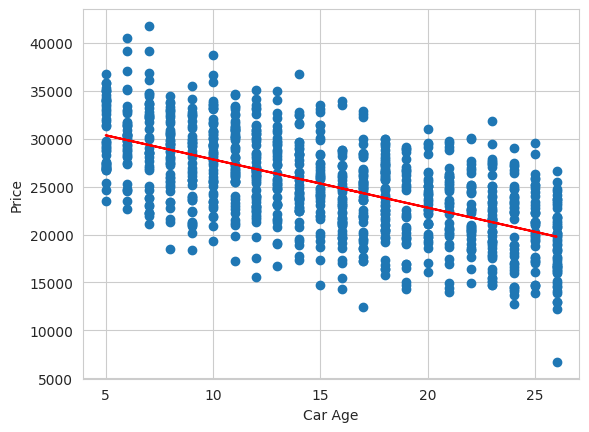

In [35]:
plt.scatter(df_model_main['Car Age'],df_model_main['Price'])
plt.plot(X_train_reshaped,lr.predict(X_train_reshaped),color='red')
plt.xlabel('Car Age')
plt.ylabel('Price')

In [36]:
y_pred = lr.predict(X_test_reshaped)

comparison = pd.DataFrame({
    'Actual Price':    y_test.values,
    'Predicted Price': y_pred.flatten(),
    'Difference':      y_test.values - y_pred.flatten()
}, index=y_test.index)  

print(comparison)

     Actual Price  Predicted Price    Difference
37   16604.498170     19782.560224  -3178.062054
726  24531.174724     21294.138690   3237.036034
846  32431.531353     29355.890510   3075.640843
295  40538.382064     29859.749998  10678.632066
924  30434.529368     29859.749998    574.779370
..            ...              ...           ...
839  23566.247511     24317.295623   -751.048112
810  16363.006005     21797.998179  -5434.992174
930  17309.141320     24821.155111  -7512.013791
616  21952.607630     29355.890510  -7403.282879
809  25710.803679     28348.171532  -2637.367853

[200 rows x 3 columns]


In [37]:
m = lr.coef_

In [38]:
b = lr.intercept_

In [39]:
# y =mx+c

m * 26 + b

array([19782.56022426])

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test_reshaped)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 3400.48
MSE  : 16989190.75
RMSE : 4121.79
R²   : 0.3728


## Multiple Linear Regression


In [41]:
df_model.sample(5)

,Engine Size,Mileage,Price,Car Age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
728,1.7,117373,21200.279221,16,0,0,0,0,0,0,0,1,0,1,1
222,1.6,54645,31414.914572,5,0,1,0,0,0,0,0,0,0,0,1
943,4.4,54698,33202.296708,10,0,0,0,0,0,0,1,0,1,0,1
336,2.0,62598,20127.079817,19,0,0,1,0,0,1,0,0,1,0,1
716,1.3,186968,16728.037649,13,1,0,0,0,0,0,0,0,0,1,1


In [42]:
print(df_model_main.columns.tolist())

['Engine Size', 'Mileage', 'Price', 'Car Age']


In [43]:
X = df_model_main.drop(columns=['Price'])
y = df_model_main['Price']

In [44]:

print("X shape:", X.shape)
print("y shape:", y.shape) 

X shape: (1000, 3)
y shape: (1000,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)  
print("X_test :", X_test.shape) 
print("y_train:", y_train.shape)  
print("y_test :", y_test.shape) 

X_train: (800, 3)
X_test : (200, 3)
y_train: (800,)
y_test : (200,)


In [46]:
from sklearn.linear_model import LinearRegression

lr_mlr = LinearRegression()
lr_mlr.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [47]:
coefficients = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': lr_mlr.coef_
})

In [48]:
print(coefficients)
print(f"\nIntercept (β0): {lr_mlr.intercept_:.2f}")

       Feature  Coefficient
0  Engine Size  1970.274141
1      Mileage    -0.048727
2      Car Age  -516.561425

Intercept (β0): 32243.45


In [49]:
y_pred_mlr = lr_mlr.predict(X_test)

print(y_pred_mlr[:5])

[25709.03491728 29624.37747305 26855.48566177 27525.39806887
 27835.64868557]


In [50]:
comparison_mlr = pd.DataFrame({
    'Actual Price':    y_test.values,
    'Predicted Price': y_pred_mlr.flatten(),
    'Difference':      y_test.values - y_pred_mlr.flatten()
}, index=y_test.index)

print(comparison_mlr)

     Actual Price  Predicted Price   Difference
521  27902.287879     25709.034917  2193.252962
737  30526.272863     29624.377473   901.895390
740  26754.650724     26855.485662  -100.834937
660  28641.336358     27525.398069  1115.938289
411  28425.173270     27835.648686   589.524584
..            ...              ...          ...
408  29503.558296     26285.251436  3218.306859
332  26579.614909     26603.955791   -24.340883
208  25966.845649     22936.261992  3030.583657
613  27664.288735     28168.492095  -504.203360
78   17198.895951     18608.042969 -1409.147018

[200 rows x 3 columns]


In [51]:
mae_mlr  = mean_absolute_error(y_test, y_pred_mlr)
mse_mlr  = mean_squared_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr   = r2_score(y_test, y_pred_mlr)

print(f"MAE  : {mae_mlr:.2f}")
print(f"MSE  : {mse_mlr:.2f}")
print(f"RMSE : {rmse_mlr:.2f}")
print(f"R²   : {r2_mlr:.4f}")

MAE  : 1787.37
MSE  : 4893381.48
RMSE : 2212.10
R²   : 0.8212


In [52]:

print(f"{'Metric':<10} {'SLR (Car Age)':<20} {'MLR (3 features)'}")

print(f"{'MAE':<10} {mae:<20.2f} {mae_mlr:.2f}")
print(f"{'RMSE':<10} {rmse:<20.2f} {rmse_mlr:.2f}")
print(f"{'R²':<10} {r2:<20.4f} {r2_mlr:.4f}")


Metric     SLR (Car Age)        MLR (3 features)
MAE        3400.48              1787.37
RMSE       4121.79              2212.10
R²         0.3728               0.8212


## Trying MLR with all columns

In [ ]:
print(df_model_full.columns.tolist())

In [54]:
X = df_model_full.drop(columns=['Price'])
y = df_model_full['Price']

In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape) 

X shape: (1000, 14)
y shape: (1000,)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)  
print("X_test :", X_test.shape) 
print("y_train:", y_train.shape)  
print("y_test :", y_test.shape) 

X_train: (800, 14)
X_test : (200, 14)
y_train: (800,)
y_test : (200,)


In [57]:
from sklearn.linear_model import LinearRegression

lr_mlr = LinearRegression()
lr_mlr.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [58]:
coefficients = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': lr_mlr.coef_
})

In [59]:
print(coefficients)
print(f"\nIntercept (β0): {lr_mlr.intercept_:.2f}")

                Feature  Coefficient
0           Engine Size  1968.237084
1               Mileage    -0.048835
2               Car Age  -518.304810
3              Make_BMW    94.745403
4             Make_Ford   122.462235
5            Make_Honda  -135.643103
6           Make_Toyota    32.766893
7         Model_Model B   -44.541570
8         Model_Model C   -78.331858
9         Model_Model D   310.769080
10        Model_Model E  -266.084077
11   Fuel Type_Electric   -83.722784
12     Fuel Type_Petrol    17.318774
13  Transmission_Manual    37.938605

Intercept (β0): 32273.51


In [60]:
y_pred_mlr = lr_mlr.predict(X_test)

print(y_pred_mlr[:5])

[25695.70851693 29413.2917892  26781.43215542 27492.50089817
 27578.32713543]


In [61]:
comparison_mlr = pd.DataFrame({
    'Actual Price':    y_test.values,
    'Predicted Price': y_pred_mlr.flatten(),
    'Difference':      y_test.values - y_pred_mlr.flatten()
}, index=y_test.index)

print(comparison_mlr)

     Actual Price  Predicted Price   Difference
521  27902.287879     25695.708517  2206.579362
737  30526.272863     29413.291789  1112.981074
740  26754.650724     26781.432155   -26.781431
660  28641.336358     27492.500898  1148.835460
411  28425.173270     27578.327135   846.846134
..            ...              ...          ...
408  29503.558296     26579.703150  2923.855146
332  26579.614909     26649.700658   -70.085750
208  25966.845649     22764.500067  3202.345582
613  27664.288735     28274.784546  -610.495811
78   17198.895951     18441.282049 -1242.386098

[200 rows x 3 columns]


In [63]:
mae_mlrf  = mean_absolute_error(y_test, y_pred_mlr)
mse_mlrf  = mean_squared_error(y_test, y_pred_mlr)
rmse_mlrf = np.sqrt(mse_mlrf)
r2_mlrf   = r2_score(y_test, y_pred_mlr)

print(f"MAE  : {mae_mlrf:.2f}")
print(f"MSE  : {mse_mlrf:.2f}")
print(f"RMSE : {rmse_mlrf:.2f}")
print(f"R²   : {r2_mlrf:.4f}")

MAE  : 1810.55
MSE  : 5005471.21
RMSE : 2237.29
R²   : 0.8171


### by adding all column to the model it make it even worse so it is best to use the top 3 column of this table